### Importando de pacotes


In [609]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

# Style customizado
stylesheet_url = "https://raw.githubusercontent.com/dhaitz/matplotlib-stylesheets/master/pitayasmoothie-light.mplstyle"



### Importação e limpeza de Dados

In [620]:
df = pd.read_csv("../data/raw/steam_games.csv")

cols_to_drop = ["Estimated owners", "Peak CCU", "Required age", "About the game",
                "Supported languages", "Full audio languages", "Reviews", "Website",
                "Support url", "Support email", "Achievements", "Average playtime forever",
                "Median playtime forever", "Median playtime two weeks", "Developers",
                "Tags", "Score rank", "Metacritic url", "Header image", "Notes"]
df = df.drop(columns=cols_to_drop)

df["Release date"] = pd.to_datetime(df["Release date"], errors="coerce")

df["Year"] = df["Release date"].dt.year
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72934 entries, 0 to 72933
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   AppID                       72934 non-null  int64         
 1   Name                        72932 non-null  object        
 2   Release date                72810 non-null  datetime64[ns]
 3   Price                       72934 non-null  float64       
 4   DLC count                   72934 non-null  int64         
 5   Windows                     72934 non-null  bool          
 6   Mac                         72934 non-null  bool          
 7   Linux                       72934 non-null  bool          
 8   Metacritic score            72934 non-null  int64         
 9   User score                  72934 non-null  int64         
 10  Positive                    72934 non-null  int64         
 11  Negative                    72934 non-null  int64     

None

In [593]:
missing_percent = (df.isna().sum() / df.shape[0]) * 100
missing_percent.sort_values(ascending=False)

Movies                        7.083116
Categories                    4.812570
Publishers                    3.861025
Genres                        3.473003
Screenshots                   1.901719
Name                          0.002742
Positive                      0.000000
Average playtime two weeks    0.000000
Recommendations               0.000000
Negative                      0.000000
AppID                         0.000000
Metacritic score              0.000000
Linux                         0.000000
Mac                           0.000000
Windows                       0.000000
DLC count                     0.000000
Price                         0.000000
Release date                  0.000000
User score                    0.000000
dtype: float64

# Respondendo perguntas

### Pergunta 1: Quais são os dez jogos mais bem avaliados, de acordo com o Metacritic? No caso de notas repetidas, ordenar os jogos de acordo com suas datas de lançamento (do mais velho para o mais recente).  

In [610]:
df_top10 = df.sort_values(
    by=["Metacritic score", "Release date"],
    ascending=[False, True]
)

response_question1 = df_top10[["Name", "Metacritic score", "Release date"]].drop_duplicates().head(10)
display(response_question1)


,Name,Metacritic score,Release date
45752,Disco Elysium - The Final Cut,97,2019-10-15
64935,Persona 5 Royal,97,2022-10-20
49557,Half-Life,96,1998-11-08
36775,Half-Life 2,96,2004-11-16
32406,BioShock™,96,2007-08-21
57205,Grand Theft Auto V,96,2015-04-13
28170,Portal 2,95,2011-04-18
12746,Sid Meier's Civilization® IV,94,2006-10-25
37184,QUAKE,94,2007-08-03
19291,The Elder Scrolls IV: Oblivion® Game of the Ye...,94,2009-06-16


### Pergunta 2: Para jogos de role-playing, qual o número médio e máximo de: DLCs, avaliações positivas, avaliações negativas e materiais de demonstração (número de capturas de tela e filmes, somados)?  

In [597]:
def count_links(cell):
    if pd.isna(cell) or cell == "":
        return 0
    return len(cell.split(","))

df["count_demos"] = df["Screenshots"].apply(count_links) + df["Movies"].apply(count_links)

In [598]:
df_rpg = df[df["Genres"].str.contains("RPG", case=False, na=False)]

mean_values = df_rpg[["DLC count", "Positive", "Negative", "count_demos"]].mean().round(2)
max_values = df_rpg[["DLC count", "Positive", "Negative", "count_demos"]].max()

response_question2 = pd.DataFrame([mean_values, max_values], index=["Média", "Máximo"])

display(response_question2)

,DLC count,Positive,Negative,count_demos
Média,0.95,1516.41,247.17,11.32
Máximo,2366.00,964983.00,129925.00,187.00


### Pergunta 3: Quais são as cinco empresas que mais publicam jogos pagos na plataforma? Para tais empresas, qual o número médio e mediano de avaliações positivas de seus jogos pagos?  

In [611]:

df_paid = df[df["Price"] > 0]

top_publishers = (
    df_paid["Publishers"]
    .value_counts()
    .head(5)
    .index
)

df_top_publishers = df_paid[df_paid["Publishers"].isin(top_publishers)]

response_question3 = (
    df_top_publishers
    .groupby("Publishers")["Positive"]
    .agg(["mean", "median", "count"])
    .sort_values(by="count", ascending=False)
)

display(response_question3)
 

,mean,median,count
Publishers,,,
Big Fish Games,7.363431,5.0,443
8floor,4.460251,3.0,239
Strategy First,276.450617,23.0,162
Laush Studio,19.777070,12.0,157
HH-Games,10.538462,9.0,156


### Pergunta 4: O número de jogos que suportam o sistema operacional Linux cresceu entre 2018 e 2022?  

In [612]:
df_linux = df[df["Linux"] == True]
response_question4 = df_linux["Year"].value_counts().sort_index().loc[2018:2022]
display(response_question4)


Year
2018.0    1187
2019.0     922
2020.0    1082
2021.0    1210
2022.0    1311
Name: count, dtype: int64

### Pergunta 5: Quais são os 5 jogos com maior tempo médio de jogo nas últimas duas semanas e seus respectivos generos e preços.

In [601]:
top5_playtime = df.sort_values(
    by="Average playtime two weeks", ascending=False
).head(5)

response_question5 = top5_playtime[["Name", "Average playtime two weeks", "Genres", "Price"]]

display(response_question5)

,Name,Average playtime two weeks,Genres,Price
58237,America's Army: Proving Grounds,19159,"Action,Free to Play",0.00
33019,GRID,10996,"Action,Casual,Racing,Simulation,Sports",19.99
53432,Fe,10995,"Action,Adventure",19.99
2037,Need for Speed™ Payback,10994,"Action,Adventure,Racing,Sports,Strategy",29.99
36135,Plants vs. Zombies: Battle for Neighborville™,10993,"Action,Casual,Strategy",39.99


# Gerando gráficos

### Gráfico 1: Percentual de jogos que possuem suporte para cada sistema operacional. Caso um jogo suporte múltiplos sistemas operacionais, contar um “voto” para cada sistema operacional suportado.  

In [ ]:
os_cols = ["Windows", "Mac", "Linux"]
os_counts = df[os_cols].sum()
total_votes = os_counts.sum()

os_percent = (os_counts / total_votes * 100).round(2)
display(os_percent)

Windows    74.64
Mac        15.05
Linux      10.31
dtype: float64

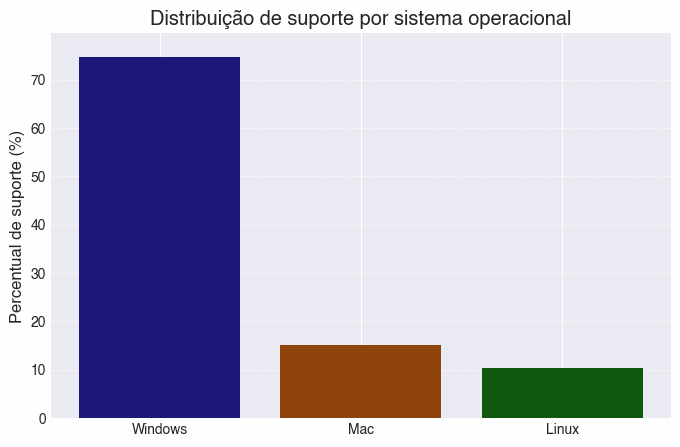

In [613]:
with mpl.style.context(stylesheet_url):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.bar(os_percent.index, os_percent.values, color=["#1C1779", "#8e440b", "#105710"])
    ax.set_ylabel("Percentual de suporte (%)")
    ax.set_title("Distribuição de suporte por sistema operacional")
    ax.set_ylim(0, os_percent.max() + 5)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

### Gráfico 2: Número total de jogos single-player do gênero Indie e estratégia lançados por ano entre 2010 e 2020 (mostrar tendência para cada gênero separadamente, mas no mesmo gráfico).  

In [616]:
df_single = df[(df["Year"] >= 2010) & (df["Year"] <= 2020)]
df_single = df_single[df_single["Categories"].str.contains("Single-player", case=False, na=False)]
df_single["Genres"] = df_single["Genres"].str.split(",")
df_single = df_single.explode("Genres").copy()
df_single["Genres"] = df_single["Genres"].str.strip()

grafic_2 = df_single[df_single["Genres"].isin(["Indie", "Strategy"])]
grafic_2 = grafic_2.groupby(["Year", "Genres"]).size().unstack(fill_value=0)
display(grafic_2)

Genres,Indie,Strategy
Year,,
2010.0,66,59
2011.0,103,82
2012.0,165,76
2013.0,261,104
2014.0,852,331
2015.0,1830,569
2016.0,2905,762
2017.0,4182,1045
2018.0,5732,1301


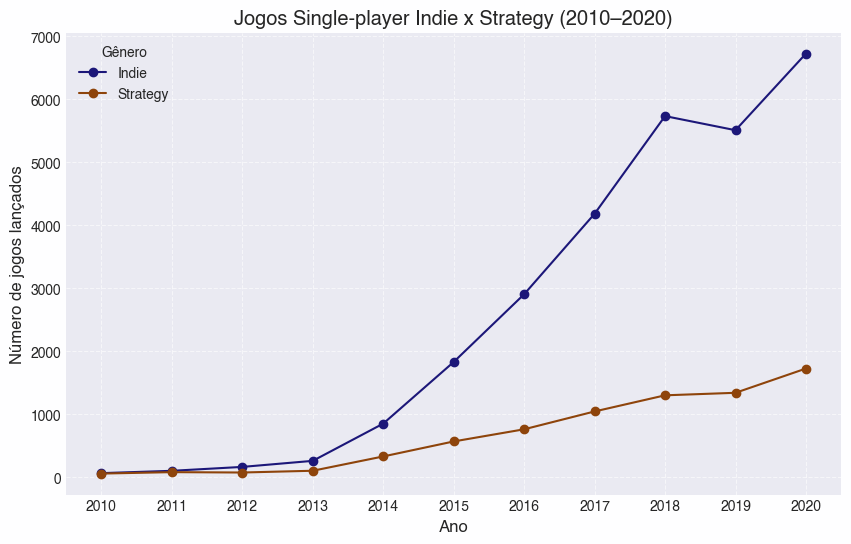

In [617]:
with mpl.style.context(stylesheet_url):
    fig, ax = plt.subplots(figsize=(10,6))
    colors = {"Indie": "#1C1779", "Strategy": "#8e440b"}
    for genre in grafic_2.columns:
        ax.plot(grafic_2.index, grafic_2[genre], marker="o", linestyle="-", color=colors[genre], label=genre)
    ax.set_title("Jogos Single-player Indie x Strategy (2010–2020)")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Número de jogos lançados")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Gênero")
    plt.xticks(grafic_2.index)
    plt.show()

### Gráfico 3: Relação de Genero dos jogos por Preço 

In [621]:
df_genres = df.copy()
df_genres["Genres"] = df_genres["Genres"].str.split(",")
df_genres = df_genres.explode("Genres")
df_genres["Genres"] = df_genres["Genres"].str.strip()

df_genres = df_genres.dropna(subset=["Genres", "Price"])

genres = df_genres["Genres"].unique()
data_to_plot = [df_genres[df_genres["Genres"]==g]["Price"] for g in genres]


/var/folders/wj/_vm5m8g909gbgb5kst1b84900000gn/T/ipykernel_1190/1010198256.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=genres, showfliers=False)


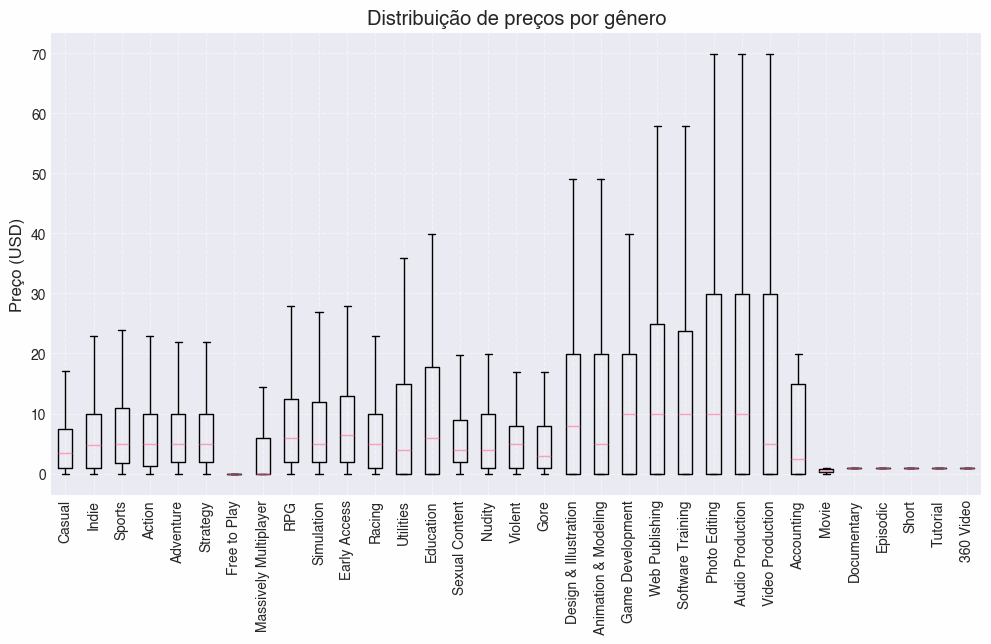

In [622]:
with mpl.style.context(stylesheet_url):
    fig, ax = plt.subplots(figsize=(12,6))
    ax.boxplot(data_to_plot, labels=genres, showfliers=False)
    ax.set_xticklabels(genres, rotation=90)
    ax.set_ylabel("Preço (USD)")
    ax.set_title("Distribuição de preços por gênero")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.show()